# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [10]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [11]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [12]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [13]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [14]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

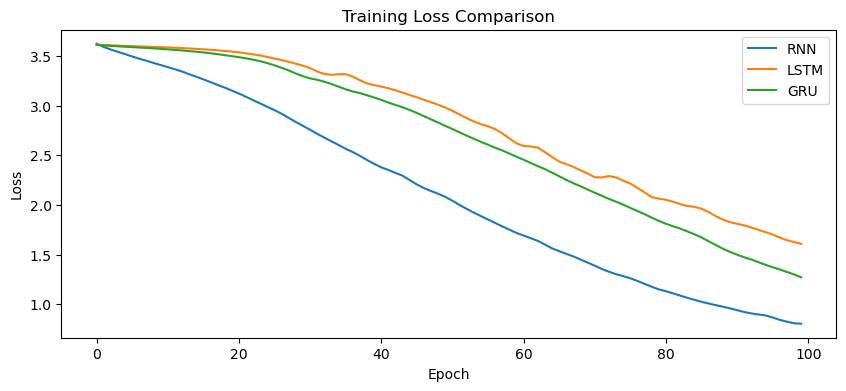

In [15]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [16]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [17]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "gru", 5))

RNN : deep learning is transforming generate intelligence sentences
LSTM: deep learning is can artificial artificial intelligence
GRU : deep learning models can generate meaningful sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**

**IMPLEMENTATION OF STUDENTS LEARNING TASKS**

**A] Replace corpus with our own Paragaph** + **Increasing Embedding** + **Hidden units 64 ---> 128** + **Generation of 10 words instead of 5** + **epoche=200** + **Story line**

In [160]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import re

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import GRU
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split

In [161]:
corpus = '''
once upon a time there was a young scientist who lived in a small town surrounded by mountains and forests. the scientist was fascinated by nature and spent countless hours observing plants 
animals and rivers. every day the scientist recorded observations in a notebook and tried to
understand the patterns that existed in the natural world.

one morning the scientist discovered a rare plant growing near a stream.
the plant had unusual leaves and produced flowers with bright colors. 
curious about its properties the scientist collected samples and brought them 
to the laboratory for further analysis. experiments revealed that the plant contained 
compounds that could potentially be used in medicine.

as news of the discovery spread researchers from different regions
became interested in studying the plant. teams collaborated to investigate 
its genetic structure growth conditions and possible applications. they shared
data exchanged ideas and conducted field studies to learn more about the species.

months of research led to significant findings. scientists discovered that 
the plant could survive in harsh environmental conditions and showed resistance 
to several diseases. these characteristics made it valuable for agricultural development. 
farmers hoped that similar traits could be introduced into important crops.

the research project continued to expand and attracted support from universities 
industries and government organizations. advanced technologies such as dna 
sequencing machine learning and bioinformatics were used to analyze large amounts of data. 
the integration of these technologies accelerated the pace of discovery.

students joined the project and gained practical experience in scientific 
research. they learned how to design experiments collect samples analyze results 
and present findings. the project inspired many young learners to pursue careers in science and technology.

after several years the research team successfully developed new crop varieties 
based on their findings. these crops demonstrated improved productivity disease 
resistance and environmental adaptability. communities benefited from increased food 
production and reduced agricultural losses.

the success of the project highlighted the importance of curiosity collaboration 
and innovation. it demonstrated how scientific research can address real world challenges 
and improve quality of life. the scientist who first discovered the unusual plant became a 
respected leader in the scientific community and continued to inspire future generations.
'''

In [162]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 225


In [163]:
input_sequences = []

for line in corpus.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):

        n_gram_seq = token_list[:i+1]

        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

In [164]:
import numpy as np

X = input_sequences[:, :-1]

y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (330, 31)
y shape: (330,)


**VANILLA RNN**: 

In [186]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

rnn_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    SimpleRNN(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("Vanilla RNN Training Completed")

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0091 - loss: 5.4088    
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0576 - loss: 5.2049 
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0818 - loss: 5.0298 
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0818 - loss: 4.9127 
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0970 - loss: 4.8000 
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1242 - loss: 4.6857 
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1455 - loss: 4.5365 
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2061 - loss: 4.3646 
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2606 - loss: 4.1613 
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3485 - loss: 3.9420 
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3879 - loss: 3.7094 
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/st

**LSTM**: Long Short-Term Memory (LSTM) is an advanced type of Recurrent Neural Network (RNN) designed to process sequential data.

In [187]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    LSTM(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("LSTM Training Completed")

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.0242 - loss: 5.4125    
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0667 - loss: 5.2993
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0606 - loss: 5.1272
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0515 - loss: 5.0364
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0727 - loss: 4.9896
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0636 - loss: 4.9436
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0727 - loss: 4.9058
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0758 - loss: 4.8765
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0727 - loss: 4.7985
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0727 - loss: 4.7194
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0758 - loss: 4.6273 
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms

**GRU**

In [188]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    GRU(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("GRU Training Completed")

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.0303 - loss: 5.4126   
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0818 - loss: 5.3672
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0606 - loss: 5.1922    
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0697 - loss: 5.0063
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0545 - loss: 4.9398
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0727 - loss: 4.8810
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0606 - loss: 4.8128
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0788 - loss: 4.7225
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1242 - loss: 4.6011
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1364 - loss: 4.4536
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.1485 - loss: 4.2775
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 22

##Accuracy Comparison

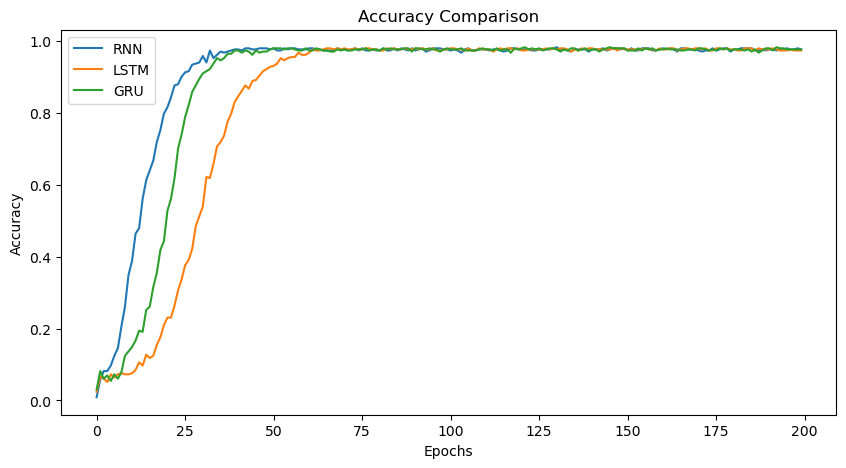

In [189]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['accuracy'],
    label='RNN'
)

plt.plot(
    lstm_history.history['accuracy'],
    label='LSTM'
)

plt.plot(
    gru_history.history['accuracy'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()

plt.show()

##Loss Comparison

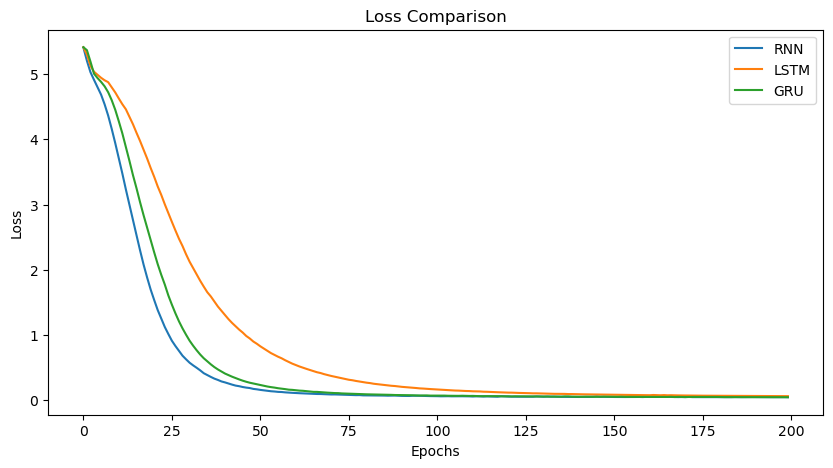

In [190]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['loss'],
    label='RNN'
)

plt.plot(
    lstm_history.history['loss'],
    label='LSTM'
)

plt.plot(
    gru_history.history['loss'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()

plt.show()

TEXT GENERATION:

In [191]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(
                token_list,
                verbose=0
            ),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:

                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

TESTING

In [192]:
print("\nRNN Output:")
print(generate_text(rnn_model,
                    "the scientist",
                    10))

print("\nLSTM Output:")
print(generate_text(lstm_model,
                    "the scientist",
                    10))

print("\nGRU Output:")
print(generate_text(gru_model,
                    "the scientist",
                    10))


RNN Output:
the scientist of these technologies accelerated the pace of discovery collaboration highlighted

LSTM Output:
the scientist could survive in harsh environmental conditions and showed resistance and

GRU Output:
the scientist discovered the unusual plant became a young scientist who lived


Next word prediction

In [193]:
seed = "one morning"

print(generate_text(
    lstm_model,
    seed,
    10
))

one morning the scientist discovered a rare plant growing near a stream


Compare Generate Text Quality

In [194]:
prompt = "students joined"

print(generate_text(rnn_model,prompt,10))
print(generate_text(lstm_model,prompt,10))
print(generate_text(gru_model,prompt,10))

students joined the project and gained practical experience in scientific notebook and
students joined the project and gained practical experience in scientific scientific scientific
students joined the project and gained practical experience in scientific community and


Random Prompt Technique

In [195]:
print(generate_text(
    lstm_model,
    "research",
    10
))

research they learned how to design experiments collect samples analyze results


In [196]:
print(generate_text(
    gru_model,
    "research",
    10
))

research they learned how to design experiments collect samples analyze results


In [197]:
print(generate_text(
    lstm_model,
    "research",
    10
))

research they learned how to design experiments collect samples analyze results


In [198]:
print(generate_text(
    lstm_model,
    "the scientists discovered",10
))

the scientists discovered of the project highlighted the importance of curiosity collaboration collaboration


In [199]:
print(generate_text(
    gru_model,
    "the scientists discovered",10
))

the scientists discovered that the plant contained collaborated to investigate careers in science


In [200]:
print(generate_text(
    rnn_model,
    "the scientists discovered",10
))

the scientists discovered the project highlighted the importance of curiosity collaboration highlighted curiosity


In [201]:
print(generate_text(
    lstm_model,
    "months of research",
    10
))

months of research led to significant findings scientists discovered that the plant contained


In [202]:
print(generate_text(
    gru_model,
    "months of research",
    10
))

months of research led to significant findings scientists discovered that the plant contained


In [203]:
print(generate_text(
    rnn_model,
    "months of research",
    10
))

months of research led to significant findings scientists discovered that unusual plant became


In [204]:
print(generate_text(
    gru_model,
    "after several years",
    10
))

after several years the research team successfully developed new crop varieties varieties varieties


In [205]:
print(generate_text(
    rnn_model,
    "after several years",
    10
))

after several years the research team successfully developed new crop varieties samples findings


In [206]:
print(generate_text(
    lstm_model,
    "after several years",
    10
))

after several years the research team successfully developed new crop varieties varieties varieties


**B]  Replace corpus with our own Paragaph** + **Increasing Embedding** + **Hidden units 64 ---> 128** + **Generation of 10 words instead of 5** + **Epoche=200** + **Song Lyrics**

In [207]:
corpus=""" 
Walking down the neon street tonight
The city shadows dancing in the light
I hear a echo calling out your name
But everyday the rules remain the same

Oh we are running through the midnight rain
Trying to forget all of the silent pain
Break the chains and let the rhythm flow
Into the places where we used to go

The ticking clock is staring from the wall
I wait in silence watching shadows fall
A plastic heart inside a paper town
We build it up just to pull it down

Oh we are running through the midnight rain
Trying to forget all of the silent pain
Break the chains and let the rhythm flow
Into the places where we used to go

Just let it go
In the midnight rain
We find our way again
"""

In [208]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 74


In [209]:
input_sequences = []

for line in corpus.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):

        n_gram_seq = token_list[:i+1]

        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

In [210]:
import numpy as np

X = input_sequences[:, :-1]

y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (117, 8)
y shape: (117,)


*Vanila RNN*

In [211]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

rnn_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    SimpleRNN(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history_200 = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("Vanilla RNN Training Completed")

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.0598 - loss: 4.2807   
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1368 - loss: 4.0744 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1368 - loss: 3.8801 
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1368 - loss: 3.7863 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1453 - loss: 3.6349 
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2479 - loss: 3.5277
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2735 - loss: 3.4026
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2821 - loss: 3.2534 
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3077 - loss: 3.1056 
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3504 - loss: 2.9581
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3932 - loss: 2.8087 
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0

*LSTM*

In [212]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    LSTM(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history_200 = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("LSTM Training Completed")

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.0684 - loss: 4.3000   
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1368 - loss: 4.2687 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1368 - loss: 4.2179 
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1368 - loss: 4.1246 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1368 - loss: 3.9907 
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1368 - loss: 3.9753
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1368 - loss: 3.9124
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1368 - loss: 3.8890
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1368 - loss: 3.8450
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1368 - loss: 3.8078
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1453 - loss: 3.7727
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.14

*GRU*

In [213]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    GRU(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history_200 = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("GRU Training Completed")

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.0598 - loss: 4.2991
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1368 - loss: 4.2661 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1368 - loss: 4.2283 
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1368 - loss: 4.1729 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1368 - loss: 4.0796 
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1368 - loss: 3.9538 
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.1368 - loss: 3.8839
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1368 - loss: 3.8040 
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.1368 - loss: 3.7655 
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1368 - loss: 3.7033
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1368 - loss: 3.6466
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.14

##ACCURACY##

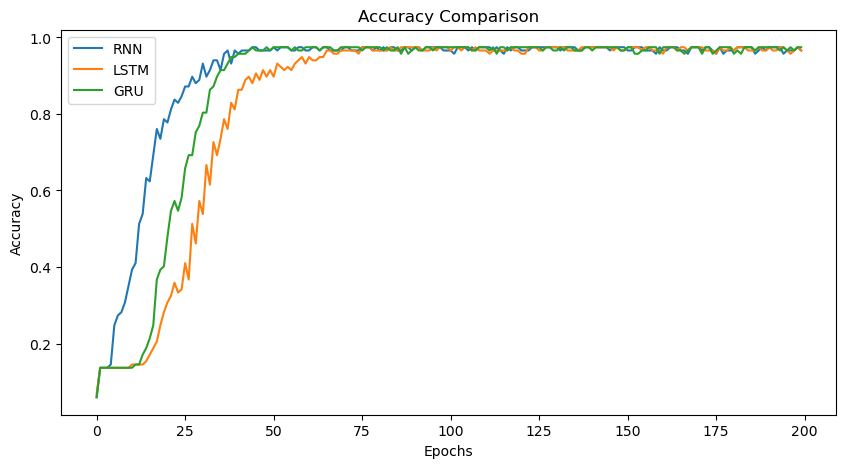

In [214]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    rnn_history_200.history['accuracy'],
    label='RNN'
)

plt.plot(
    lstm_history_200.history['accuracy'],
    label='LSTM'
)

plt.plot(
    gru_history_200.history['accuracy'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()

plt.show()

##LOSS##

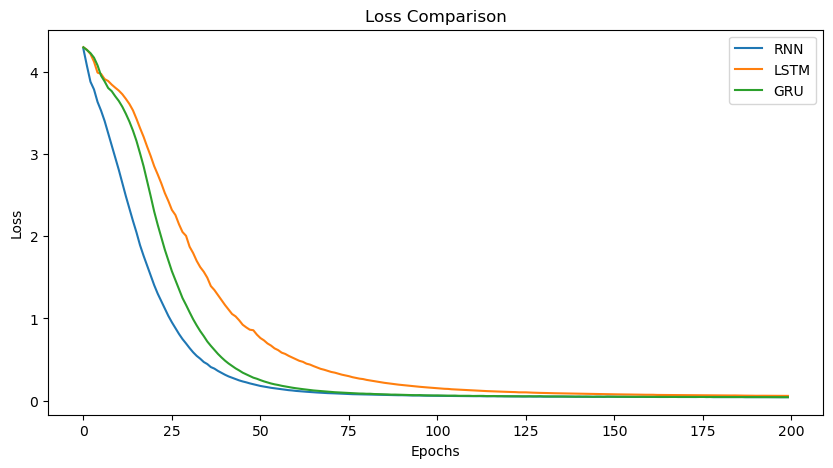

In [215]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history_200.history['loss'],
    label='RNN'
)

plt.plot(
    lstm_history_200.history['loss'],
    label='LSTM'
)

plt.plot(
    gru_history_200.history['loss'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()

plt.show()

In [216]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(
                token_list,
                verbose=0
            ),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:

                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

*TESTING*

In [217]:
print("\nRNN Output:")
print(generate_text(rnn_model,
                    "street tonight",
                    10))

print("\nLSTM Output:")
print(generate_text(lstm_model,
                    "street tonight",
                    10))

print("\nGRU Output:")
print(generate_text(gru_model,
                    "street tonight",
                    10))


RNN Output:
street tonight the ticking clock is staring from the wall pain is

LSTM Output:
street tonight down the neon street tonight flow flow name name name

GRU Output:
street tonight it up just to pull it down the neon street


*NEXT WORD PREDICTION*

In [218]:
seed = "echo calling"

print(generate_text(
    lstm_model,
    seed,
    10
))

echo calling the neon street tonight town name name name name down


*COMPARE GENERATE TEXT QUALITY*

In [221]:
prompt = "rhythm"

print("RNN-Vanilla--->",generate_text(rnn_model,prompt,20))
print("LSTM--->",generate_text(lstm_model,prompt,10))
print("GRU--->",generate_text(gru_model,prompt,10))

RNN-Vanilla---> rhythm the city shadows dancing in the light pain fall name rhythm go wall fall name down the midnight rain tonight
LSTM---> rhythm the city shadows dancing the light flow name name name
GRU---> rhythm everyday the rules remain the same same wall wall wall


*RANDOM PROMPT TECHNIQUE*

In [222]:
print("LSTM",generate_text(
    lstm_model,
    "ticking clock",
    10
))
print("RNN-VANILLA:",generate_text(
    rnn_model,
    "ticking clock",
    10
))
print("GRU:",generate_text(
    gru_model,
    "ticking clock",
    10
))

LSTM ticking clock down the neon street tonight tonight flow name name name
RNN-VANILLA: ticking clock is staring from the wall pain is staring from the
GRU: ticking clock it up just to pull it down the neon street


In [223]:
print("LSTM:",generate_text(
    lstm_model,
    "rhythm",
    10
))
print("RNN-VANILLA:",generate_text(
    rnn_model,
    "rhythm",
    10
))
print("GRU:",generate_text(
    gru_model,
    "rhythm",
    10
))

LSTM: rhythm the city shadows dancing the light flow name name name
RNN-VANILLA: rhythm the city shadows dancing in the light pain fall name
GRU: rhythm everyday the rules remain the same same wall wall wall


**C]  Replace corpus with our own Paragaph** + **Increasing Embedding** + **Hidden units 64 ---> 128** + **Generation of 10 words instead of 5** + **Epoche=200** + **Shakespeare text**

In [224]:
corpus="""HAMLET:
To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die—to sleep—
No more; and by a sleep to say we end
The heart-ache and the thousand natural shocks
That flesh is heir to: 'tis a consummation
Devoutly to be wish'd. To die, to sleep;
To sleep, perchance to dream—ay, there's the rub:
For in that sleep of death what dreams may come,
When we have shuffled off this mortal coil,
Must give us pause. There's the respect
That makes calamity of so long life.

OPHELIA:
My lord, I have remembrances of yours,
That I have longed long to re-deliver;
I pray you, now receive them.

HAMLET:
No, not I; I never gave you aught.

OPHELIA:
My honour'd lord, you know right well you did;
And, with them, words of so sweet breath composed
As made the things more precious: their perfume lost,
Take these again; for to the noble mind
Rich gifts wax poor when givers prove unkind.
There, my lord.

MACBETH:
Tomorrow, and tomorrow, and tomorrow,
Creeps in this petty pace from day to day
To the last syllable of recorded time,
And all our yesterdays have lighted fools
The way to dusty death. Out, out, brief candle!
Life's but a walking shadow, a poor player
That struts and frets his hour upon the stage
And then is heard no more: it is a tale
Told by an idiot, full of sound and fury,
Signifying nothing.
 """

In [225]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 165


In [226]:
input_sequences = []

for line in corpus.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):

        n_gram_seq = token_list[:i+1]

        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

In [227]:
import numpy as np

X = input_sequences[:, :-1]

y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (232, 9)
y shape: (232,)


**VANILLA RNN**

In [228]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

rnn_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    SimpleRNN(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("Vanilla RNN Training Completed")

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.0345 - loss: 5.1000   
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.0603 - loss: 4.9145 
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0603 - loss: 4.7562 
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0733 - loss: 4.6135
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0819 - loss: 4.5064
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1336 - loss: 4.3868 
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1422 - loss: 4.2483
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1767 - loss: 4.1078 
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2371 - loss: 3.9428
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2759 - loss: 3.7788
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3405 - loss: 3.5911 
Epoch 12/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3

**LSTM**

In [229]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    LSTM(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("LSTM Training Completed")

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.0517 - loss: 5.1037   
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0603 - loss: 5.0667 
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0603 - loss: 4.9578
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0603 - loss: 4.7993
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.0603 - loss: 4.7338 
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0603 - loss: 4.6942 
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0603 - loss: 4.6607 
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.0647 - loss: 4.6204 
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0733 - loss: 4.5766 
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0690 - loss: 4.5253 
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0733 - loss: 4.4677 
Epoch 12/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy:

**GRU**

In [230]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    GRU(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("GRU Training Completed")

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.0259 - loss: 5.1040    
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0733 - loss: 5.0664 
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0603 - loss: 5.0019
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0603 - loss: 4.8619
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0603 - loss: 4.7269
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0603 - loss: 4.6812
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0603 - loss: 4.6281
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0862 - loss: 4.5818 
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1078 - loss: 4.5274
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1034 - loss: 4.4574 
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0991 - loss: 4.3767
Epoch 12/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1

*Accuracy Comparison*

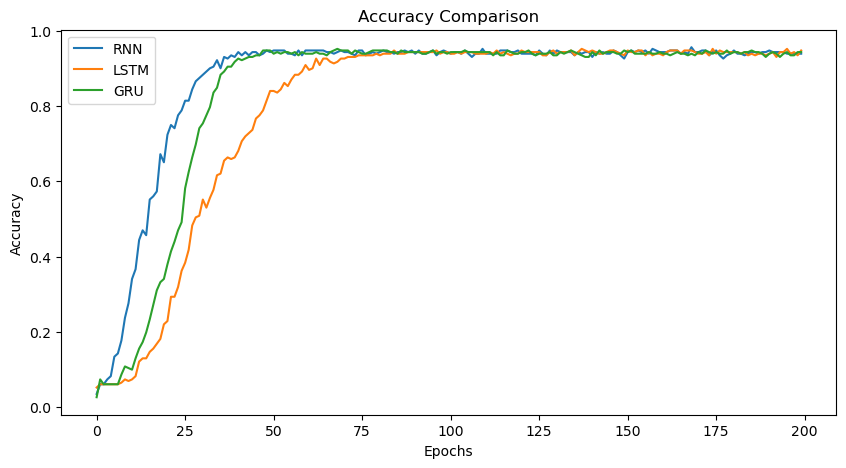

In [231]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['accuracy'],
    label='RNN'
)

plt.plot(
    lstm_history.history['accuracy'],
    label='LSTM'
)

plt.plot(
    gru_history.history['accuracy'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()

plt.show()

*Loss Comparison*

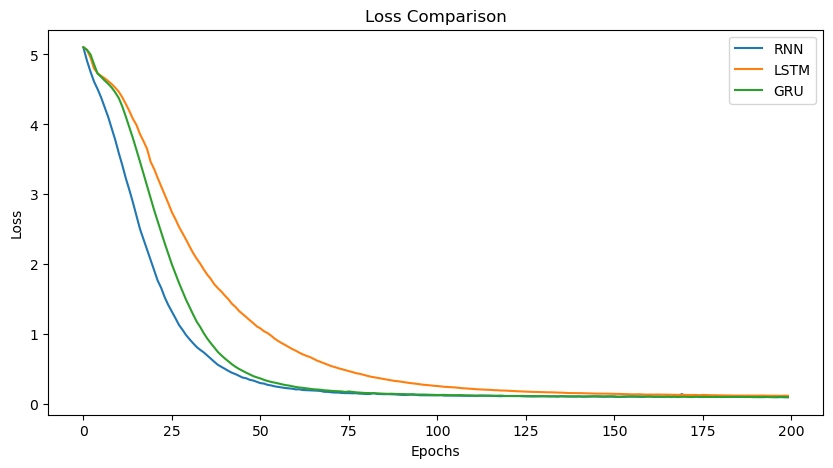

In [232]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['loss'],
    label='RNN'
)

plt.plot(
    lstm_history.history['loss'],
    label='LSTM'
)

plt.plot(
    gru_history.history['loss'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()

plt.show()

**Testing and Text Generation**

In [234]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(
                token_list,
                verbose=0
            ),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:

                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [235]:
print("\nRNN Output:")
print(generate_text(rnn_model,
                    "To be, or not to be,",
                    10))

print("\nLSTM Output:")
print(generate_text(lstm_model,
                    "To be, or not to be,",
                    10))

print("\nGRU Output:")
print(generate_text(gru_model,
                    "To be, or not to be,",
                    10))


RNN Output:
To be, or not to be, that is the question to sleep perchance to dream—ay there's

LSTM Output:
To be, or not to be, that is the question question question candle candle come come

GRU Output:
To be, or not to be, that is the question mind to suffer question suffer stage


In [236]:
seed = "Hamlet"

print(generate_text(
    lstm_model,
    seed,
    10
))

Hamlet in this petty pace to day to day that is


In [238]:
prompt = "Tomorrow"

print(generate_text(rnn_model,prompt,10))
print(generate_text(lstm_model,prompt,10))
print(generate_text(gru_model,prompt,10))

Tomorrow and tomorrow and tomorrow and tomorrow and tomorrow and tomorrow
Tomorrow and tomorrow and tomorrow and tomorrow and tomorrow tomorrow and
Tomorrow and tomorrow and tomorrow and tomorrow and tomorrow tomorrow stage


In [239]:
print(generate_text(
    lstm_model,
    "Thou marshal",
    10
))

Thou marshal to the last syllable of recorded time may come come


In [240]:
print(generate_text(
    gru_model,
    "Thou marshal",
    10
))

Thou marshal give us pause there's the respect mind to rub stage


In [241]:
print(generate_text(
    lstm_model,
    "Thou marshal",
    10
))

Thou marshal to the last syllable of recorded time may come come


**D]  Replace corpus with our own Paragaph** + **Increasing Embedding** + **Hidden units 64 ---> 128** + **Generation of 10 words instead of 5** + **Epoche=200** + **chatbot data**

In [242]:
corpus="""[
  {"input": "hey listen i have been trying to login since morning but it keeps saying wrong password", "target": "i understand your frustration let me help you unlock your account please share your registered email id"},
  {"input": "can you check why my order 4092 is still not shipped yet", "target": "let me check that status for you immediately hold on a second while i pull up order 4092"},
  {"input": "my money got deducted twice for a single transaction what should i do", "target": "please do not worry this is usually a bank sync issue the duplicate amount will automatically clear within 48 hours"},
  {"input": "i want a refund right now your product is completely broken", "target": "i am deeply sorry to hear that please share a picture of the damage so i can process a full refund or replacement"},
  {"input": "how do i change my delivery address for an active shipment", "target": "if the package has not left our warehouse you can update it in settings otherwise i can contact the courier partner for you"},
  {"input": "is there any discount code available for new users today", "target": "yes absolutely you can use the promo code welcome10 at checkout to get a flat ten percent discount on your first order"},
  {"input": "hello anyone here to help me with a billing issue", "target": "hello yes i am here to assist you please tell me what went wrong with your bill"},
  {"input": "can i cancel my subscription before the next renewal date", "target": "yes you can cancel anytime via your profile dashboard under the subscriptions tab without any cancellation fee"},
  {"input": "your app is crashing every time i open the cart page", "target": "sorry about that bug please try clearing your app cache or update to the latest version from the app store"},
  {"input": "thank you so much you saved my day", "target": "you are very welcome it was my absolute pleasure to help you have a fantastic day ahead"}
]
 """

In [243]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 191


In [244]:
input_sequences = []

for line in corpus.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):

        n_gram_seq = token_list[:i+1]

        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

In [245]:
import numpy as np

X = input_sequences[:, :-1]

y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (316, 35)
y shape: (316,)


**VANILLA RNN**

In [246]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

rnn_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    SimpleRNN(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("Vanilla RNN Training Completed")

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0032 - loss: 5.2671   
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0981 - loss: 5.0461
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1297 - loss: 4.8748
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1614 - loss: 4.6995
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2057 - loss: 4.5201 
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2247 - loss: 4.3146 
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3133 - loss: 4.1280
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3829 - loss: 3.9476
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4525 - loss: 3.7558
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5570 - loss: 3.5377 
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5506 - loss: 3.2936 
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/s

**LSTM**

In [247]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    LSTM(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("LSTM Training Completed")

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.0316 - loss: 5.2506
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.0380 - loss: 5.1833
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.0380 - loss: 5.0264 
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0475 - loss: 4.9371
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0475 - loss: 4.9136    
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0443 - loss: 4.8348
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0570 - loss: 4.7780
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0506 - loss: 4.7198
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0665 - loss: 4.6289
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0759 - loss: 4.5452
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0854 - loss: 4.4353
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms

**GRU**

In [248]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    GRU(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("GRU Training Completed")

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.0063 - loss: 5.2494   
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0949 - loss: 5.2142
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0696 - loss: 5.1245
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0380 - loss: 4.9567
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0538 - loss: 4.8781
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0538 - loss: 4.8187
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0823 - loss: 4.7476
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0823 - loss: 4.6634
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0538 - loss: 4.5606
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0759 - loss: 4.4370
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1899 - loss: 4.3067
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/s

*ACCURACY*

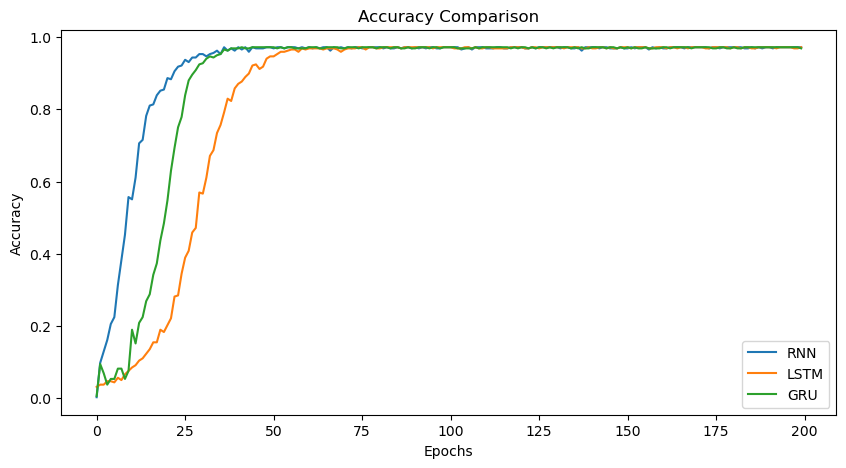

In [249]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['accuracy'],
    label='RNN'
)

plt.plot(
    lstm_history.history['accuracy'],
    label='LSTM'
)

plt.plot(
    gru_history.history['accuracy'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()

plt.show()

*LOSS*

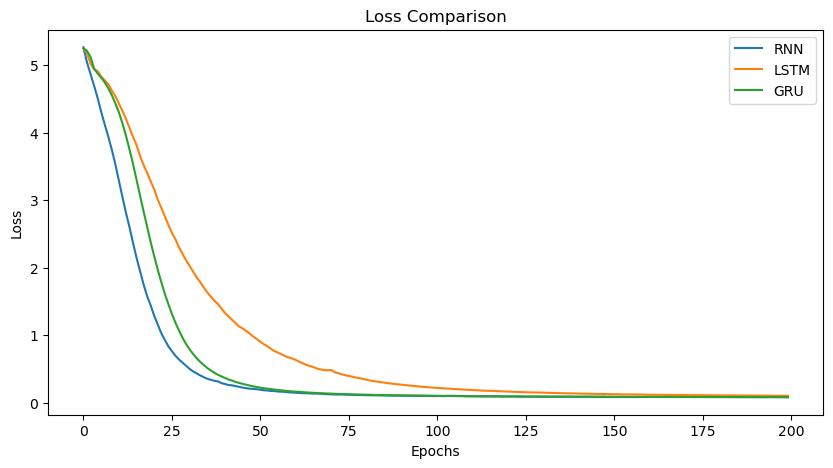

In [250]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['loss'],
    label='RNN'
)

plt.plot(
    lstm_history.history['loss'],
    label='LSTM'
)

plt.plot(
    gru_history.history['loss'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()

plt.show()

*TEXT GENERATION AND TESTING*

In [251]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(
                token_list,
                verbose=0
            ),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:

                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [253]:
print("\nRNN Output:")
print(generate_text(rnn_model,
                    "my money got deducted twice for a single transaction what should i do",
                    30))

print("\nLSTM Output:")
print(generate_text(lstm_model,
                    "my money got deducted twice for a single transaction what should i do",
                    30))

print("\nGRU Output:")
print(generate_text(gru_model,
                    "my money got deducted twice for a single transaction what should i do",
                    30))


RNN Output:
my money got deducted twice for a single transaction what should i do target please do not worry this is usually a bank sync issue the duplicate amount will automatically clear within 48 hours a immediately welcome10 at checkout to get a flat

LSTM Output:
my money got deducted twice for a single transaction what should i do target please do not worry this is usually a bank sync issue the duplicate amount will automatically clear within 48 hours hours hours hours hours hours hours hours hours hours

GRU Output:
my money got deducted twice for a single transaction what should i do target please do not worry this is usually a bank sync issue the duplicate amount will automatically clear within 48 hours hours fee fee hours hours hours fee fee percent


In [255]:
seed = "can i cancel my subscription"

print(generate_text(
    lstm_model,
    seed
))

can i cancel my subscription before the next renewal date target yes you can cancel


In [256]:
prompt = "what went wrong with your bill"

print(generate_text(rnn_model,prompt))
print(generate_text(lstm_model,prompt))
print(generate_text(gru_model,prompt))

what went wrong with your bill is crashing every time i open the cart page target
what went wrong with your bill is crashing every time i open the page target sorry
what went wrong with your bill is completely broken target i am deeply sorry to hear


In [257]:
print(generate_text(
    lstm_model,
    "what went wrong with your bill",
    10
))
print(generate_text(
    gru_model,
    "what went wrong with your bill",
    10
))
print(generate_text(
    lstm_model,
    "what went wrong with your bill",
    10
))

what went wrong with your bill is crashing every time i open the page target sorry
what went wrong with your bill is completely broken target i am deeply sorry to hear
what went wrong with your bill is crashing every time i open the page target sorry


In [263]:
print(generate_text(
    lstm_model,
    "welcome"
))

welcome i want a refund right now your product is completely


In [262]:
print(generate_text(
    gru_model,
    "welcome"
))

welcome i want a refund right now your product is completely


In [261]:
print(generate_text(
    rnn_model,
    "welcome"
))

welcome i can i cancel my subscription before the next renewal


**E]  Replace corpus with our own Paragaph** + **Increasing Embedding** + **Hidden units 64 ---> 128** + **Generation of 10 words instead of 5** + **Epoche=200** + **PDF TEXT**

In [270]:
from pypdf import PdfReader

reader = PdfReader("BIOTECH.pdf")

corpus = ""

for page in reader.pages:
    text = page.extract_text()

    if text:
        corpus += text + " "

print(corpus[:4000])

Biotechnology is a rapidly growing field that combines biology, technology, and engineering to develop 
innovative solutions for challenges in healthcare, agriculture, industry, and environmental sustainability. By 
utilizing living organisms, biological systems, and cellular processes, biotechnology has significantly 
improved the quality of human life and contributed to scientific advancement across the world. 
One of the most important applications of biotechnology is in healthcare. Scientists use biotechnology to 
develop vaccines, diagnostic tools, and therapeutic drugs that help prevent and treat diseases. Recombinant 
DNA technology has enabled the production of essential medicines such as insulin, growth hormones, and 
monoclonal antibodies. Advances in biotechnology have also led to personalized medicine, where treatments 
can be tailored according to an individual's genetic profile, improving effectiveness and reducing side 
effects. 
In agriculture, biotechnology plays a cru

In [273]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 539


In [274]:
input_sequences = []

for line in corpus.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):

        n_gram_seq = token_list[:i+1]

        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

In [275]:
import numpy as np

X = input_sequences[:, :-1]

y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1283, 21)
y shape: (1283,)


**VANILLA RNN**

In [276]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

rnn_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    SimpleRNN(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("Vanilla RNN Training Completed")

Epoch 1/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0452 - loss: 6.0567    
Epoch 2/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0592 - loss: 5.6676 
Epoch 3/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0624 - loss: 5.5612     
Epoch 4/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0725 - loss: 5.4400 
Epoch 5/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1044 - loss: 5.2196 
Epoch 6/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1481 - loss: 4.9005 
Epoch 7/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1941 - loss: 4.5262 
Epoch 8/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2432 - loss: 4.1290 
Epoch 9/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3172 - loss: 3.7303 
Epoch 10/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4279 - loss: 3.3569 
Epoch 11/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5043 - loss: 2.9672 
Epoch 12/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6m

**LSTM**

In [277]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    LSTM(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("LSTM Training Completed")

Epoch 1/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0569 - loss: 6.0972
Epoch 2/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0592 - loss: 5.6956
Epoch 3/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0592 - loss: 5.6220
Epoch 4/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0592 - loss: 5.5762
Epoch 5/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0624 - loss: 5.4838
Epoch 6/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0663 - loss: 5.3522
Epoch 7/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0756 - loss: 5.2031
Epoch 8/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1037 - loss: 5.0151
Epoch 9/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1247 - loss: 4.8057
Epoch 10/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1551 - loss: 4.5821
Epoch 11/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1824 - loss: 4.3506
Epoch 12/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

**GRU**

In [278]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    GRU(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("GRU Training Completed")

Epoch 1/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0499 - loss: 6.1493    
Epoch 2/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0592 - loss: 5.7004
Epoch 3/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0592 - loss: 5.5990
Epoch 4/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0663 - loss: 5.4756    
Epoch 5/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0928 - loss: 5.2664
Epoch 6/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1380 - loss: 4.9557
Epoch 7/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1754 - loss: 4.5802
Epoch 8/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2182 - loss: 4.2189
Epoch 9/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2541 - loss: 3.8715
Epoch 10/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3157 - loss: 3.5349
Epoch 11/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3562 - loss: 3.2137
Epoch 12/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 1

*ACCURACY*

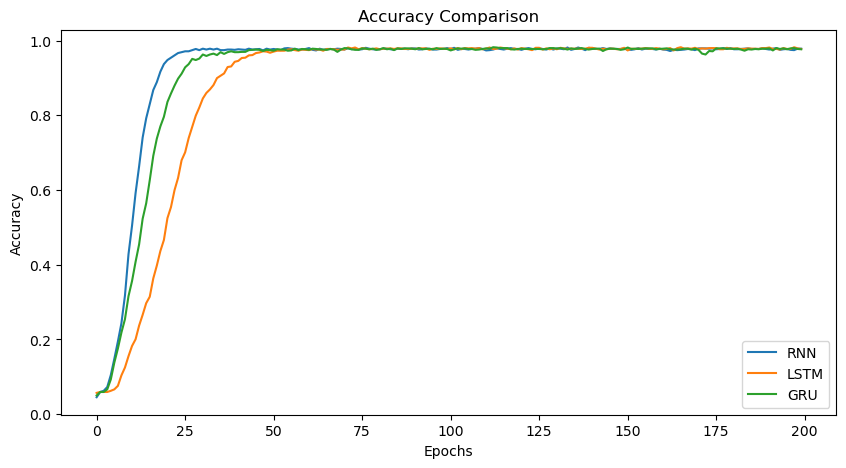

In [279]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['accuracy'],
    label='RNN'
)

plt.plot(
    lstm_history.history['accuracy'],
    label='LSTM'
)

plt.plot(
    gru_history.history['accuracy'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()

plt.show()

*LOSS*

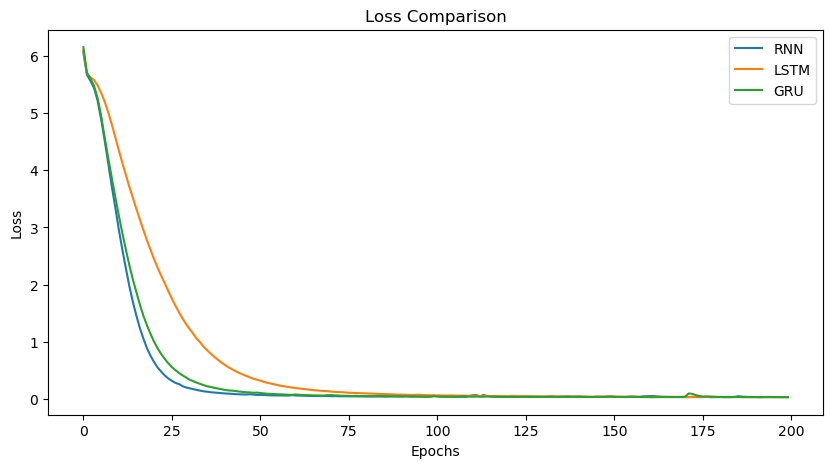

In [280]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['loss'],
    label='RNN'
)

plt.plot(
    lstm_history.history['loss'],
    label='LSTM'
)

plt.plot(
    gru_history.history['loss'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()

plt.show()

*TEXT GENERATION and TESTING*

In [281]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(
                token_list,
                verbose=0
            ),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:

                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [283]:
print("\nRNN Output:")
print(generate_text(rnn_model,
                    "Environmental biotechnology ",
                    10))

print("\nLSTM Output:")
print(generate_text(lstm_model,
                    "Environmental biotechnology ",
                    10))

print("\nGRU Output:")
print(generate_text(gru_model,
                    "Environmental biotechnology ",
                    10))


RNN Output:
Environmental biotechnology  focuses on using biological processes to solve environmental problems focuses

LSTM Output:
Environmental biotechnology  focuses on using biological processes to solve environmental problems environmental

GRU Output:
Environmental biotechnology  focuses on using biological processes to solve environmental problems work
